# Tieback vs Standalone Concept Comparison

This notebook compares a host tieback, standalone FPSO and fixed-platform concept on one normalized production, price, OPEX and tax basis. The concept templates provide CAPEX, schedule, power and emissions assumptions; the cash-flow model is then rebuilt with the same production profile for all alternatives.


In [1]:
from pathlib import Path
import json
import sys
import subprocess

for package in ['matplotlib', 'pandas']:
    try:
        __import__(package)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

import matplotlib.pyplot as plt
import pandas as pd

try:
    NOTEBOOK_DIR = Path(__vsc_ipynb_file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd().resolve()
CHAPTER_DIR = NOTEBOOK_DIR.parent
FIGURES_DIR = CHAPTER_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
BOOK_DIR = CHAPTER_DIR
for candidate in [CHAPTER_DIR] + list(CHAPTER_DIR.parents):
    if (candidate / 'book.yaml').exists():
        BOOK_DIR = candidate
        break
PROJECT_ROOT = BOOK_DIR
for candidate in [BOOK_DIR] + list(BOOK_DIR.parents):
    if (candidate / 'pom.xml').exists() and (candidate / 'devtools' / 'neqsim_dev_setup.py').exists():
        PROJECT_ROOT = candidate
        break
sys.path.insert(0, str(PROJECT_ROOT / 'devtools'))
from neqsim_dev_setup import neqsim_init
ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False)
JClass = ns.JClass
GreenfieldConceptFactory = JClass('neqsim.process.fielddevelopment.concept.GreenfieldConceptFactory')
CashFlowEngine = JClass('neqsim.process.fielddevelopment.economics.CashFlowEngine')

def update_results(section, data):
    path = BOOK_DIR / 'results.json'
    results = json.loads(path.read_text(encoding='utf-8')) if path.exists() else {}
    results[section] = data
    path.write_text(json.dumps(results, indent=2), encoding='utf-8')
    return path

def java_map_to_dict(java_map):
    return {str(entry.getKey()): float(entry.getValue()) for entry in java_map.entrySet()}

print(f'Project root: {PROJECT_ROOT}')
print(f'Book directory: {BOOK_DIR}')


Project root: C:\Users\ESOL\Documents\GitHub\neqsim
Book directory: C:\Users\ESOL\Documents\GitHub\neqsim\neqsim-paperlab\books\tpg4230_field_development_and_operations_2026


## Common Production Basis

A common gas production profile is used for all concepts so the comparison focuses on development concept, cost, power, emissions and schedule rather than different reservoir assumptions.


In [2]:
templates = [
    GreenfieldConceptFactory.subseaTieback('Host tieback case'),
    GreenfieldConceptFactory.standaloneFpso('Standalone FPSO case'),
    GreenfieldConceptFactory.fixedPlatform('Fixed platform case')
]

start_year = 2028
common_gas_profile = {
    start_year + 0: 0.6e9,
    start_year + 1: 1.5e9,
    start_year + 2: 2.4e9,
    start_year + 3: 2.4e9,
    start_year + 4: 2.4e9,
    start_year + 5: 2.1e9,
    start_year + 6: 1.8e9,
    start_year + 7: 1.5e9,
    start_year + 8: 1.2e9,
    start_year + 9: 0.9e9
}

def normalized_cash_flow(template):
    engine = CashFlowEngine('NO')
    engine.setGasPrice(0.24)
    engine.setGasTariff(0.02)
    engine.setCapex(float(template.getTotalCapexMusd()), start_year - 1)
    engine.setFixedOpexPerYear(float(template.getAnnualOpexMusd()))
    engine.setOpexPercentOfCapex(0.0)
    for year, gas in common_gas_profile.items():
        engine.addAnnualProduction(int(year), 0.0, float(gas), 0.0)
    return engine.calculate(0.08)

rows = []
breakdowns = []
for template in templates:
    econ = normalized_cash_flow(template)
    rows.append({
        'concept': str(template.getCaseType()),
        'capex_MUSD': float(template.getTotalCapexMusd()),
        'annual_opex_MUSD': float(template.getAnnualOpexMusd()),
        'power_MW': float(template.getPowerMw()),
        'annual_emissions_tonnes': float(template.getAnnualEmissionsTonnes()),
        'schedule_months': int(template.getDevelopmentDurationMonths()),
        'npv_MUSD': float(econ.getNpv()),
        'irr_pct': float(econ.getIrr()) * 100.0
    })
    breakdown = java_map_to_dict(template.getCapexBreakdownMusd())
    breakdown['concept'] = str(template.getCaseType())
    breakdowns.append(breakdown)

df = pd.DataFrame(rows).sort_values('npv_MUSD', ascending=False)
breakdown_df = pd.DataFrame(breakdowns).fillna(0.0).set_index('concept')
df


,concept,capex_MUSD,annual_opex_MUSD,power_MW,annual_emissions_tonnes,schedule_months,npv_MUSD,irr_pct
0,Subsea tieback,830.0,38.2,3.0,15942.00000,36,230.404420,15.825862
2,Fixed platform,1085.0,48.4,2.0,8018.80334,60,134.271713,11.579592
1,Standalone FPSO,1815.0,77.6,2.0,8018.80334,48,-207.456366,4.901824


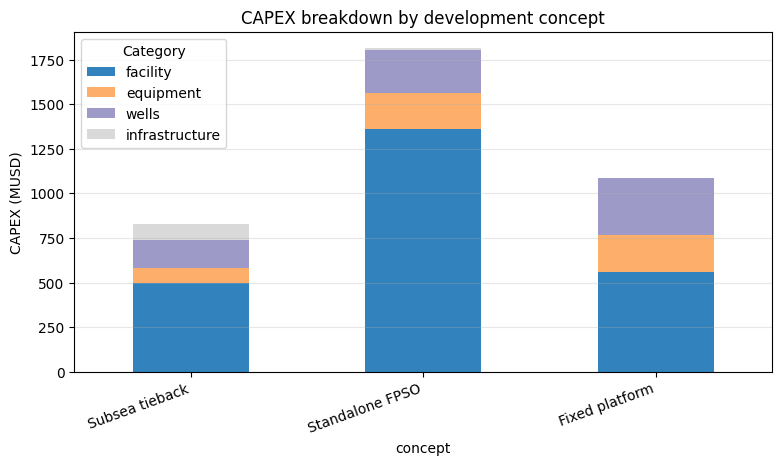

In [3]:
fig, ax = plt.subplots(figsize=(9.0, 5.0))
breakdown_df[['facility', 'equipment', 'wells', 'infrastructure']].plot(kind='bar', stacked=True, ax=ax, colormap='tab20c')
ax.set_ylabel('CAPEX (MUSD)')
ax.set_title('CAPEX breakdown by development concept')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(title='Category', loc='upper left')
fig.autofmt_xdate(rotation=20)
fig.savefig(FIGURES_DIR / 'ch24_11_concept_capex_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()


**Discussion.** *Observation.* The standalone concepts carry larger facility and infrastructure components than the tieback case. *Mechanism.* A tieback reuses host processing while standalone concepts must pay for topsides, export systems and more self-contained utilities. *Implication.* CAPEX dominates early concept screening and sets the breakeven threshold. *Recommendation.* Compare CAPEX categories before comparing a single total cost number.


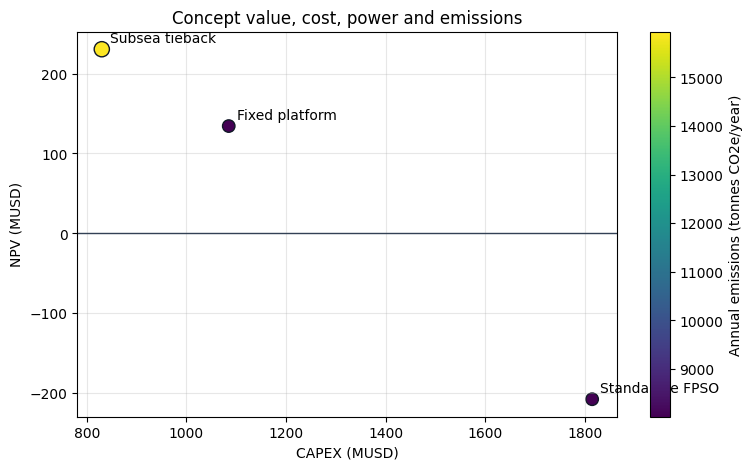

In [4]:
fig, ax = plt.subplots(figsize=(8.7, 5.0))
scatter = ax.scatter(df['capex_MUSD'], df['npv_MUSD'], s=df['power_MW'] * 40.0, c=df['annual_emissions_tonnes'], cmap='viridis', edgecolor='#111827')
for _, row in df.iterrows():
    ax.annotate(row['concept'], (row['capex_MUSD'], row['npv_MUSD']), xytext=(6, 5), textcoords='offset points')
ax.axhline(0.0, color='#334155', linewidth=1.0)
ax.set_xlabel('CAPEX (MUSD)')
ax.set_ylabel('NPV (MUSD)')
ax.set_title('Concept value, cost, power and emissions')
ax.grid(True, alpha=0.3)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Annual emissions (tonnes CO2e/year)')
fig.savefig(FIGURES_DIR / 'ch24_11_npv_capex_emissions.png', dpi=150, bbox_inches='tight')
plt.show()


**Discussion.** *Observation.* The concept with the highest NPV is not necessarily the concept with the lowest emissions or the shortest schedule. *Mechanism.* Value, power demand and emissions respond to different drivers: CAPEX timing, host reuse, processing scope and power source. *Implication.* Concept selection is multi-criteria even when economics is the headline metric. *Recommendation.* Show NPV, CAPEX, emissions and schedule together in DG2 decision material.


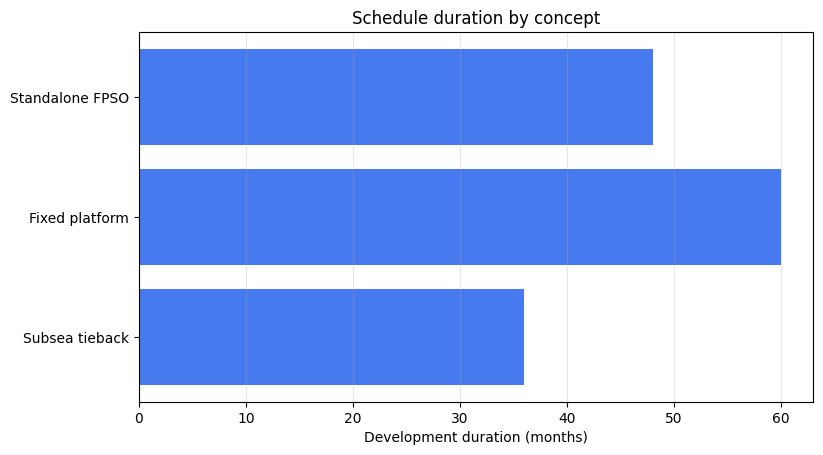

In [5]:
fig, ax = plt.subplots(figsize=(8.7, 4.8))
ax.barh(df['concept'], df['schedule_months'], color='#2563eb', alpha=0.85)
ax.set_xlabel('Development duration (months)')
ax.set_title('Schedule duration by concept')
ax.grid(True, axis='x', alpha=0.3)
fig.savefig(FIGURES_DIR / 'ch24_11_schedule_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


**Discussion.** *Observation.* Brownfield tiebacks usually reach first production faster than standalone greenfield concepts. *Mechanism.* Host reuse reduces new-build scope, procurement interfaces and commissioning complexity. *Implication.* Schedule can offset lower plateau rates by bringing cash flow forward. *Recommendation.* Preserve first-oil timing in economics instead of comparing only undiscounted totals.


In [6]:
section = {
    'concepts': df.to_dict(orient='records'),
    'capex_breakdown': breakdown_df.reset_index().to_dict(orient='records'),
    'common_gas_profile_sm3_per_year': {str(k): v for k, v in common_gas_profile.items()},
    'best_concept': str(df.iloc[0]['concept']),
    'best_concept_npv_musd': float(df.iloc[0]['npv_MUSD']),
    'figures': [
        'figures/ch24_11_concept_capex_breakdown.png',
        'figures/ch24_11_npv_capex_emissions.png',
        'figures/ch24_11_schedule_comparison.png'
    ]
}
results_path = update_results('tieback_vs_standalone', section)
print(f'Updated {results_path}')
section


Updated C:\Users\ESOL\Documents\GitHub\neqsim\neqsim-paperlab\books\tpg4230_field_development_and_operations_2026\results.json


{'concepts': [{'concept': 'Subsea tieback',
   'capex_MUSD': 830.0,
   'annual_opex_MUSD': 38.2,
   'power_MW': 3.0,
   'annual_emissions_tonnes': 15942.0,
   'schedule_months': 36,
   'npv_MUSD': 230.40442023625397,
   'irr_pct': 15.825862400143508},
  {'concept': 'Fixed platform',
   'capex_MUSD': 1085.0,
   'annual_opex_MUSD': 48.4,
   'power_MW': 2.0,
   'annual_emissions_tonnes': 8018.80334,
   'schedule_months': 60,
   'npv_MUSD': 134.27171326828923,
   'irr_pct': 11.579591885868163},
  {'concept': 'Standalone FPSO',
   'capex_MUSD': 1815.0,
   'annual_opex_MUSD': 77.60000000000001,
   'power_MW': 2.0,
   'annual_emissions_tonnes': 8018.80334,
   'schedule_months': 48,
   'npv_MUSD': -207.45636613671982,
   'irr_pct': 4.901823770791455}],
 'capex_breakdown': [{'concept': 'Subsea tieback',
   'facility': 500.0,
   'equipment': 80.0,
   'wells': 160.0,
   'infrastructure': 90.0},
  {'concept': 'Standalone FPSO',
   'facility': 1360.0,
   'equipment': 205.0,
   'wells': 240.0,
   'i